## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, SONFIS, EarlyStopping, get_measures, Gaussian_MF

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Surface (10k)

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 32, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 32, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [7]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced= True
)

In [8]:
model.init_premises(x_train)

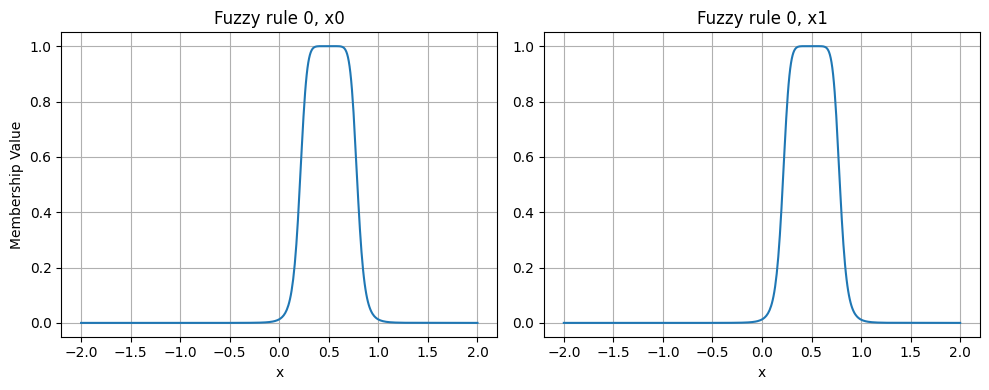

In [9]:
model.plot_premises()

### Hybrid Learning Algorithm

In [10]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [11]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [12]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [13]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [14]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 3.762582 - validation loss: 4.122478
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 2.135080 - validation loss: 2.364660
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 0.985803 - validation loss: 0.998782
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 0.632669 - validation loss: 0.614696
 -> Fuzzy rules: 5

Iteration:  4/40 - loss: 0.329742 - validation loss: 0.335751
 -> Fuzzy rules: 7

Iteration:  5/40 - loss: 0.222782 - validation loss: 0.237553
 -> Fuzzy rules: 8

Iteration:  6/40 - loss: 0.161479 - validation loss: 0.162097
 -> Fuzzy rules: 10

Iteration:  7/40 - loss: 0.137623 - validation loss: 0.138665
 -> Fuzzy rules: 12

Iteration:  8/40 - loss: 0.130629 - validation loss: 0.132574
 -> Fuzzy rules: 13

Iteration:  9/40 - loss: 0.217650 - validation loss: 0.222207
 -> Fuzzy rules: 15

Iteration: 10/40 - loss: 0.137061 - validation loss: 0.134493
 -> Fuzzy rules: 17

Iteration: 11/40 - loss: 0.137698 - validation loss: 0.136258
 -> Fuzzy rules: 18

Early stop

In [15]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.016909028204752333
RMSE: 0.1300347192281828
MAE: 0.09282356587356805
R2: 0.9952703700145278
MAPE: 12.597848136124037


In [16]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.025931851053567545
RMSE: 0.16103369539809842
MAE: 0.12490898297619776
R2: 0.9930048382282227
MAPE: 2.261147157015085


# Surface (1k)

In [17]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.1,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [18]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [19]:
train_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

test_loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), batch_size = 16, shuffle = True)
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [20]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced = True
)

In [21]:
model.init_premises(x_train)

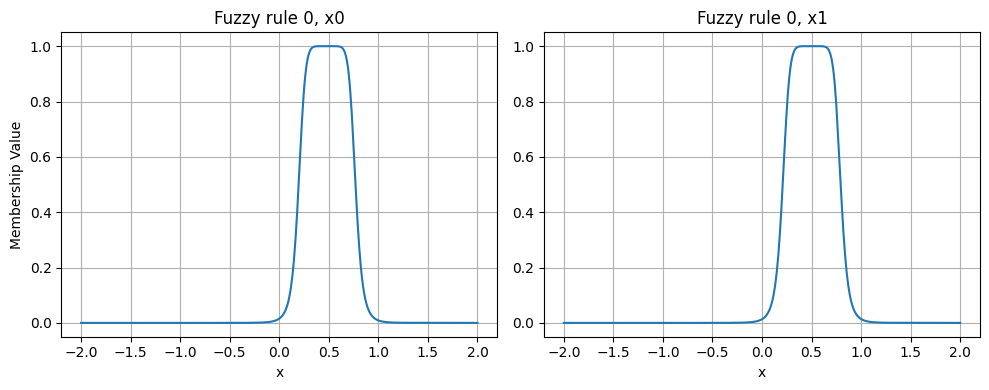

In [22]:
model.plot_premises()

### Hybrid Learning Algorithm

In [23]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=15, delta=0.01)

In [24]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [25]:
Ngrow = 400
dGrow = 0.8
Nsplit = 200
eSplit = 0.5
Nvanish = 60
lVanish = 3

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [26]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [27]:
%time sonfis(model, train_loader, verbose=True)

Iteration:  0/40 - loss: 4.784587 - validation loss: 4.313598
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 1.762843 - validation loss: 1.797421
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 1.451145 - validation loss: 1.416923
 -> Fuzzy rules: 4

Iteration:  3/40 - loss: 1.057685 - validation loss: 0.991258
 -> Fuzzy rules: 4

Iteration:  4/40 - loss: 2.908518 - validation loss: 3.172072
 -> Fuzzy rules: 6

Iteration:  5/40 - loss: 0.277311 - validation loss: 0.232137
 -> Fuzzy rules: 6

No more updates
Iteration:  6/40 - loss: 0.277311 - validation loss: 0.232137

Training finished
 -> Fuzzy rules: 6

CPU times: user 19.9 s, sys: 75.7 ms, total: 20 s
Wall time: 9.55 s


In [28]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.1659231103951451
RMSE: 0.40733660576376524
MAE: 0.2917905882996008
R2: 0.9559786284107524
MAPE: 33.22079081677849


In [29]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.1310187261812516
RMSE: 0.3619650897272437
MAE: 0.26549963313727903
R2: 0.9646664718687129
MAPE: 3.9203131262426685


# Synt 1

## Data

In [30]:
def f(x0, x1, x2):
    return (1 + x0**0.5 + x1 + x2**-1.5)

#Training
x0 = np.random.uniform(1,6,216)
x1 = np.random.uniform(1,6,216)
x2 = np.random.uniform(1,6,216)

Y = f(x0, x1, x2)


#Testing
x0_test = np.random.uniform(1.5,5.5,125)
x1_test = np.random.uniform(1.5,5.5,125)
x2_test = np.random.uniform(1.5,5.5,125)

Y_test = f(x0_test, x1_test, x2_test)

In [31]:
#Training
scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0, x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [32]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

## Model & Training

### ANFIS

In [33]:
model = ANFIS(
    input_size = 3,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced=True
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [34]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [35]:
trainer = Hybrid_learning_algorithm(
    epochs=50,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [36]:
Ngrow = 30
dGrow = 0.8
Nsplit = 40
eSplit = 0.5
Nvanish = 30
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=5, delta=0.01)
last_training_iteration = True

In [37]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [38]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 43.445016 - validation loss: 39.126117
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 0.024199 - validation loss: 0.021982
 -> Fuzzy rules: 3

Iteration:  2/40 - loss: 0.029132 - validation loss: 0.029320
 -> Fuzzy rules: 3

Iteration:  3/40 - loss: 0.023902 - validation loss: 0.030140
 -> Fuzzy rules: 5

Iteration:  4/40 - loss: 0.022473 - validation loss: 0.019770
 -> Fuzzy rules: 6

Iteration:  5/40 - loss: 0.009800 - validation loss: 0.014933
 -> Fuzzy rules: 7

Early stopping

Training finished
 -> Fuzzy rules: 2

CPU times: user 5.69 s, sys: 1.62 ms, total: 5.69 s
Wall time: 637 ms


In [39]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.004121489401725307
RMSE: 0.06419882710552668
MAE: 0.05096492683204594
R2: 0.996677359107816
MAPE: 0.008002508767875513


In [40]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.011674529522591934
RMSE: 0.10804873679313393
MAE: 0.08304503990331652
R2: 0.9942068141294196
MAPE: 0.013827045992540617


# Synt 2

## Data

In [41]:
def f(x1, x2):
    return ((np.sin(x1)*np.sin(x2))/(x1*x2))

#Training
x1 = np.random.uniform(-5,5,196)
x2 = np.random.uniform(-5,5,196)

#noise and outliers
epsilon = 0.5

G = np.random.normal(0, 0.01, 196)
H = np.random.normal(0, 0.05, 196)
F = G * (1 - epsilon) + epsilon * H

Y = f(x1, x2) + F


#Testing
x1_test = np.random.uniform(-5,5,392)
x2_test = np.random.uniform(-5,5,392)

Y_test = f(x1_test, x2_test)

In [42]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x1, x2)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x1_test,x2_test)).T
scaled_test = scaler.transform(vstack_test)

In [43]:
loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 16, shuffle = True)
x_train = loader.dataset.tensors[0]
y_train = loader.dataset.tensors[1]

In [44]:
x_train.shape

torch.Size([196, 2])

## Model & Training

### ANFIS

In [45]:
model = ANFIS(
    input_size = 2,
    fuzzy_rules = 1,
    outputs = 1,
    rule_reduced=True,
    membership_function=Gaussian_MF
)

model.init_premises(x_train)

### Hybrid Learning Algorithm

In [46]:
loss_fn = nn.functional.mse_loss
#loss_fn = nn.functional.binary_cross_entropy
#loss_fn = nn.functional.cross_entropy

optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

early_stopping = EarlyStopping(patience=10, delta=0.01)

In [47]:
trainer = Hybrid_learning_algorithm(
    epochs=10,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

### SONFIS

In [48]:
Ngrow = 20
dGrow = 0.8
Nsplit = 30
eSplit = 0.7
Nvanish = 20
lVanish = 2

max_iterations = 40

anfis_trainer = trainer

validation = 0.2
sonfis_early_stopping = EarlyStopping(patience=7, delta=0.01)
last_training_iteration = True

In [49]:
sonfis = SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    validation=validation,
    early_stopping=sonfis_early_stopping,
    last_training_iteration=last_training_iteration
)

In [50]:
%time sonfis(model, loader, verbose=True)

Iteration:  0/40 - loss: 0.643919 - validation loss: 0.350839
 -> Fuzzy rules: 2

Iteration:  1/40 - loss: 37.473765 - validation loss: 38.008450
 -> Fuzzy rules: 4

Iteration:  2/40 - loss: 22.747827 - validation loss: 24.575207
 -> Fuzzy rules: 5

Iteration:  3/40 - loss: 13.561120 - validation loss: 13.125248
 -> Fuzzy rules: 6

Iteration:  4/40 - loss: 9.148942 - validation loss: 8.605653
 -> Fuzzy rules: 6

Iteration:  5/40 - loss: 11.890786 - validation loss: 15.073797
 -> Fuzzy rules: 8

Iteration:  6/40 - loss: 6.892454 - validation loss: 7.682243
 -> Fuzzy rules: 8

No more updates
Iteration:  7/40 - loss: 6.892454 - validation loss: 7.682243

Training finished
 -> Fuzzy rules: 8

CPU times: user 5.11 s, sys: 26.8 ms, total: 5.14 s
Wall time: 988 ms


In [51]:
model.fuzzy_rules

8

In [52]:
x_test = torch.from_numpy(scaled_test)
y_test = torch.from_numpy(Y_test)

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.00248424650558388
RMSE: 0.04984221609824226
MAE: 0.0395556910213291
R2: 0.969750679189018
MAPE: 1.6022542781345597


In [53]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.0018304144402748433
RMSE: 0.0427833430235979
MAE: 0.03385836255006459
R2: 0.9744296102762838
MAPE: 1.7723836586507682
